# 🔍 Luminância v2 — Features Enriquecidas + XGBoost
**Melhorias:** FFT + HOG + blocos 4x4 + coerência + normalização local  
**Modelo:** XGBoost (substitui SVM)  
**Output:** `svm_luminance.pkl` + `scaler_luminance.pkl` (mesmo nome, drop-in replacement)

---
## Bloco 1 — Setup

In [1]:
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import sobel
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import cross_val_score

print('✅ Imports OK')

✅ Imports OK


In [5]:
# ─── CONFIGURAÇÕES ───────────────────────────────────────────────────────────
DATASET_ROOT = Path('modelos_treinamento/archive')
OUTPUT_DIR   = Path('./modelos/Luminescencia')
CACHE_DIR    = Path('./cache_lum_v2')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_REAL = DATASET_ROOT / 'train' / 'real'
TRAIN_FAKE = DATASET_ROOT / 'train' / 'fake'
TEST_REAL  = DATASET_ROOT / 'test'  / 'real'
TEST_FAKE  = DATASET_ROOT / 'test'  / 'fake'

RESIZE_TO   = (256, 256)
GRID        = 4           # grade 4x4 = 16 blocos
EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

print('✅ Configurações OK')
print(f'   Output: {OUTPUT_DIR.resolve()}')

✅ Configurações OK
   Output: /home/gustavom/Área de trabalho/tcc/Xiz9/modelos/Luminescencia


In [6]:
print(f'TRAIN_REAL: {TRAIN_REAL.resolve()}')
print(f'Existe: {TRAIN_REAL.exists()}')
print(f'Conteúdo: {list(TRAIN_REAL.iterdir())[:5]}')

TRAIN_REAL: /home/gustavom/Área de trabalho/tcc/Xiz9/modelos_treinamento/archive/train/real
Existe: True
Conteúdo: [PosixPath('modelos_treinamento/archive/train/real/0001.jpg'), PosixPath('modelos_treinamento/archive/train/real/0002.jpg'), PosixPath('modelos_treinamento/archive/train/real/0003.jpg'), PosixPath('modelos_treinamento/archive/train/real/0004.jpg'), PosixPath('modelos_treinamento/archive/train/real/0005.jpg')]


---
## Bloco 2 — Extração de Features Enriquecidas

In [7]:
def extract_luminance_features_v2(image_bytes: bytes) -> np.ndarray | None:
    """
    Extrai ~70 features de luminância enriquecidas:
    - PCA da magnitude (11 features — compatível com v1)
    - FFT da magnitude do gradiente (5 features)
    - Histograma de direções HOG (8 features)
    - Coerência local do gradiente (2 features)
    - Normalização local do gradiente (3 features)
    - Features por blocos 4x4 (16 blocos × 3 stats = 48 features)
    Total: ~77 features
    """
    try:
        img_array = np.frombuffer(image_bytes, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        if img is None:
            return None

        # ── Luminância ───────────────────────────────────────────────────────
        img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)
        img_resized = cv2.resize(img_rgb, RESIZE_TO)
        luminancia = (0.299 * img_resized[:,:,0] +
                      0.587 * img_resized[:,:,1] +
                      0.114 * img_resized[:,:,2])

        # ── Gradientes Sobel ─────────────────────────────────────────────────
        grad_x    = sobel(luminancia, axis=1)
        grad_y    = sobel(luminancia, axis=0)
        magnitude = np.sqrt(grad_x**2 + grad_y**2)
        direcao   = np.arctan2(grad_y, grad_x)

        # ── 1. Features PCA (compatível v1 — 11 features) ────────────────────
        from sklearn.decomposition import PCA
        N_COMP = 30
        n   = min(N_COMP, min(magnitude.shape))
        pca = PCA(n_components=n, svd_solver='randomized', random_state=42)
        pca.fit(magnitude)
        var = pca.explained_variance_ratio_

        pca_feats = [
            float(var[0]),
            float(np.sum(var[:5])),
            float(np.sum(var[:10])),
            float(np.sum(var[:20])),
            float(-np.sum(var * np.log(var + 1e-10))),   # entropia
            float(np.std(var)),
            float(np.std(direcao)),
            float(np.mean(magnitude)),
            float(np.std(magnitude)),
            float(np.percentile(magnitude, 90)),
            float(np.mean(magnitude) / (np.std(magnitude) + 1e-10)),  # SNR
        ]

        # ── 2. FFT da magnitude do gradiente (5 features) ────────────────────
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft2(magnitude)))
        h, w    = fft_mag.shape
        cy, cx  = h // 2, w // 2
        Y, X    = np.ogrid[:h, :w]
        dist    = np.sqrt((X - cx)**2 + (Y - cy)**2)
        md      = np.sqrt(cx**2 + cy**2)
        e_low   = float(np.sum(fft_mag[dist <= md * 0.1]**2))
        e_mid   = float(np.sum(fft_mag[(dist > md * 0.1) & (dist <= md * 0.4)]**2))
        e_high  = float(np.sum(fft_mag[dist > md * 0.4]**2))
        e_tot   = e_low + e_mid + e_high + 1e-12
        fft_feats = [
            e_low  / e_tot,
            e_mid  / e_tot,
            e_high / e_tot,
            e_high / (e_low + 1e-12),                    # razão high/low
            float(np.std(np.log1p(fft_mag))),            # uniformidade espectral
        ]

        # ── 3. Histograma de direções HOG (8 features) ───────────────────────
        # Imagens reais têm distribuição mais uniforme
        # Imagens de IA tendem a concentrar direções
        hist_dir, _ = np.histogram(direcao, bins=8, range=(-np.pi, np.pi))
        hist_dir    = hist_dir / (hist_dir.sum() + 1e-10)
        hog_feats   = hist_dir.tolist()

        # ── 4. Coerência local do gradiente (2 features) ─────────────────────
        # Mede se gradientes vizinhos apontam na mesma direção
        coer_v = float(np.mean(np.cos(direcao[:-1, :] - direcao[1:, :])))
        coer_h = float(np.mean(np.cos(direcao[:, :-1] - direcao[:, 1:])))
        coer_feats = [coer_v, coer_h]

        # ── 5. Normalização local (3 features) ───────────────────────────────
        # Remove variações de iluminação — normaliza pelo contexto local
        blur      = cv2.GaussianBlur(magnitude.astype(np.float32), (15, 15), 0)
        mag_norm  = magnitude / (blur.astype(np.float64) + 1e-6)
        norm_feats = [
            float(np.mean(mag_norm)),
            float(np.std(mag_norm)),
            float(np.percentile(mag_norm, 95)),
        ]

        # ── 6. Features por blocos 4x4 (48 features) ─────────────────────────
        # Captura variações regionais que features globais perdem
        bh, bw = RESIZE_TO[0] // GRID, RESIZE_TO[1] // GRID
        block_feats = []
        for i in range(GRID):
            for j in range(GRID):
                bloco = magnitude[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
                block_feats.append(float(np.mean(bloco)))
                block_feats.append(float(np.std(bloco)))
                block_feats.append(float(np.percentile(bloco, 90)))

        # ── Concatenar tudo ───────────────────────────────────────────────────
        all_feats = (pca_feats + fft_feats + hog_feats +
                     coer_feats + norm_feats + block_feats)

        result = np.array(all_feats, dtype=np.float32)

        # Segurança: substituir NaN/Inf por 0
        result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)
        return result

    except Exception:
        return None


# Teste rápido
test_files = list(TRAIN_REAL.rglob('*'))
test_files = [f for f in test_files if f.suffix.lower() in EXTENSIONS]
sample = extract_luminance_features_v2(test_files[0].read_bytes())
print(f'✅ Features extraídas: {len(sample)} dimensões')
print(f'   NaN: {np.isnan(sample).sum()} | Inf: {np.isinf(sample).sum()}')

✅ Features extraídas: 77 dimensões
   NaN: 0 | Inf: 0


---
## Bloco 3 — Extração do Dataset Completo

In [9]:
from concurrent.futures import ThreadPoolExecutor

def list_images(folder: Path):
    return [p for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]

def process(args):
    fpath, label = args
    try:
        feat = extract_luminance_features_v2(fpath.read_bytes())
        return (feat, label) if feat is not None else None
    except Exception:
        return None

def extract_split(real_folder, fake_folder, prefix, n_workers=8):
    cache_X = CACHE_DIR / f'{prefix}_X.npy'
    cache_y = CACHE_DIR / f'{prefix}_y.npy'

    if cache_X.exists() and cache_y.exists():
        print(f'📦 Carregando {prefix} do cache...')
        return np.load(cache_X), np.load(cache_y)

    all_files = ([(f, 0) for f in list_images(real_folder)] +
                 [(f, 1) for f in list_images(fake_folder)])

    print(f'⚙️  Extraindo {prefix} ({len(all_files):,} imagens) com {n_workers} workers...')

    X, y = [], []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for result in tqdm(executor.map(process, all_files),
                           total=len(all_files), desc=prefix):
            if result is not None:
                X.append(result[0])
                y.append(result[1])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int8)
    np.save(cache_X, X)
    np.save(cache_y, y)
    print(f'   ✅ {len(X):,} amostras')
    return X, y


X_train, y_train = extract_split(TRAIN_REAL, TRAIN_FAKE, 'train')
X_test,  y_test  = extract_split(TEST_REAL,  TEST_FAKE,  'test')

print(f'\n📐 Train: {X_train.shape} | Test: {X_test.shape}')
print(f'📊 Train — Real: {(y_train==0).sum():,} | Fake: {(y_train==1).sum():,}')
print(f'📊 Test  — Real: {(y_test==0).sum():,}  | Fake: {(y_test==1).sum():,}')
X_test,  y_test  = extract_split(TEST_REAL,  TEST_FAKE,  'test')

print(f'\n📐 Train: {X_train.shape} | Test: {X_test.shape}')
print(f'📊 Train — Real: {(y_train==0).sum():,} | Fake: {(y_train==1).sum():,}')
print(f'📊 Test  — Real: {(y_test==0).sum():,}  | Fake: {(y_test==1).sum():,}')

⚙️  Extraindo train (48,000 imagens) com 8 workers...


train:  58%|█████████████████████████████████████████████████████████████████████████████████████▌                                                             | 27933/48000 [52:49<29:58, 11.16it/s]Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48000/48000 [1:24:58<00:00,  9.42it/s]


   ✅ 47,993 amostras
⚙️  Extraindo test (12,000 imagens) com 8 workers...


test:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 11902/12000 [20:35<00:07, 12.38it/s]Corrupt JPEG data: 106 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [20:44<00:00,  9.64it/s]

   ✅ 11,997 amostras

📐 Train: (47993, 77) | Test: (11997, 77)
📊 Train — Real: 23,993 | Fake: 24,000
📊 Test  — Real: 5,997  | Fake: 6,000
📦 Carregando test do cache...

📐 Train: (47993, 77) | Test: (11997, 77)
📊 Train — Real: 23,993 | Fake: 24,000
📊 Test  — Real: 5,997  | Fake: 6,000


---
## Bloco 4 — Normalização

In [10]:
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'✅ Scaler aplicado')
print(f'   NaN train: {np.isnan(X_train_s).sum()} | NaN test: {np.isnan(X_test_s).sum()}')

✅ Scaler aplicado
   NaN train: 0 | NaN test: 0


---
## Bloco 5 — Treinamento XGBoost

In [11]:
# Calcular peso para balancear classes
n_real = (y_train == 0).sum()
n_fake = (y_train == 1).sum()
scale_pos_weight = n_real / n_fake
print(f'⚖️  scale_pos_weight: {scale_pos_weight:.2f}')

model = XGBClassifier(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,
    eval_metric        = 'auc',
    early_stopping_rounds = 30,
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0,
)

print('🚀 Treinando XGBoost...')
model.fit(
    X_train_s, y_train,
    eval_set=[(X_test_s, y_test)],
    verbose=False
)

y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
auc     = roc_auc_score(y_test, y_proba)

print(f'\n📊 Resultados:')
print(f'   Accuracy : {acc:.4f}')
print(f'   F1       : {f1:.4f}')
print(f'   AUC-ROC  : {auc:.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Real", "IA"])}')

⚖️  scale_pos_weight: 1.00
🚀 Treinando XGBoost...

📊 Resultados:
   Accuracy : 0.8419
   F1       : 0.8448
   AUC-ROC  : 0.9200

              precision    recall  f1-score   support

        Real       0.86      0.82      0.84      5997
          IA       0.83      0.86      0.84      6000

    accuracy                           0.84     11997
   macro avg       0.84      0.84      0.84     11997
weighted avg       0.84      0.84      0.84     11997



---
## Bloco 6 — Análise de Eficiência e Viés

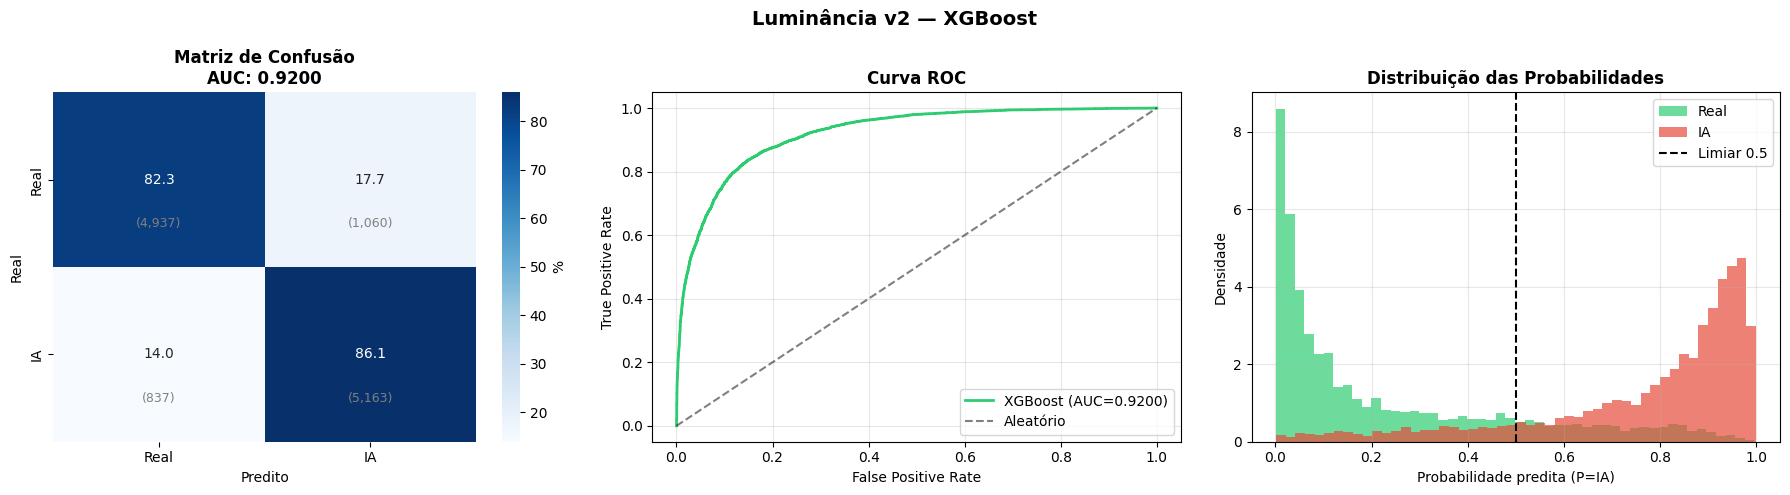


🔬 Análise de viés:
   Falsos Positivos (Real → IA): 1,060 (17.7%)
   Falsos Negativos (IA → Real): 837 (14.0%)
   Zona de incerteza (35%-65%): 15.0%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusão
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.75, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=9, color='gray')
axes[0].set_title(f'Matriz de Confusão\nAUC: {auc:.4f}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'XGBoost (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Distribuição de probabilidades
axes[2].hist(y_proba[y_test==0], bins=50, alpha=0.7, color='#2ecc71',
             label='Real', density=True)
axes[2].hist(y_proba[y_test==1], bins=50, alpha=0.7, color='#e74c3c',
             label='IA', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', label='Limiar 0.5')
axes[2].set_xlabel('Probabilidade predita (P=IA)')
axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição das Probabilidades', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Luminância v2 — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'resultados_lum_v2.png', dpi=120, bbox_inches='tight')
plt.show()

# Análise de viés
fn = cm[0, 1]  # Real predito como IA
fp = cm[1, 0]  # IA predito como Real
print(f'\n🔬 Análise de viés:')
print(f'   Falsos Positivos (Real → IA): {fn:,} ({fn/cm[0].sum()*100:.1f}%)')
print(f'   Falsos Negativos (IA → Real): {fp:,} ({fp/cm[1].sum()*100:.1f}%)')

uncertain = ((y_proba > 0.35) & (y_proba < 0.65)).mean() * 100
print(f'   Zona de incerteza (35%-65%): {uncertain:.1f}%')

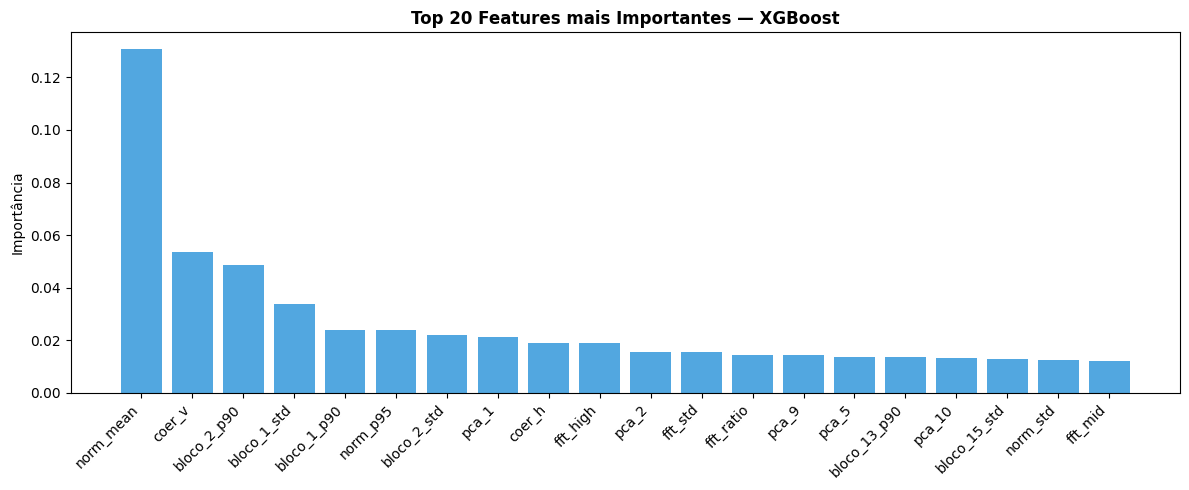

In [13]:
# Importância das features
feature_names = (
    [f'pca_{i}' for i in range(11)] +
    ['fft_low', 'fft_mid', 'fft_high', 'fft_ratio', 'fft_std'] +
    [f'hog_{i}' for i in range(8)] +
    ['coer_v', 'coer_h'] +
    ['norm_mean', 'norm_std', 'norm_p95'] +
    [f'bloco_{i//3}_{["mean","std","p90"][i%3]}' for i in range(GRID*GRID*3)]
)

importances = model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.85)
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Features mais Importantes — XGBoost', fontweight='bold')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Bloco 7 — Salvar Modelos

In [14]:
joblib.dump(model,  OUTPUT_DIR / 'svm_luminance.pkl')
joblib.dump(scaler, OUTPUT_DIR / 'scaler_luminance.pkl')

print('💾 Modelos salvos:')
print(f'   {OUTPUT_DIR / "svm_luminance.pkl"}')
print(f'   {OUTPUT_DIR / "scaler_luminance.pkl"}')
print('\n✅ Drop-in replacement pronto — o service não precisa de alterações!')

💾 Modelos salvos:
   modelos/Luminescencia/svm_luminance.pkl
   modelos/Luminescencia/scaler_luminance.pkl

✅ Drop-in replacement pronto — o service não precisa de alterações!
